# Extracting and Visualizing Stock Data

## Tesla and GameStop Stock & Revenue Analysis

**Author:** Wilson Moses  
**Program:** IBM Data Science Professional Certificate  
**Project:** Python Project for Data Science

This notebook extracts historical share-price and quarterly-revenue data for Tesla and GameStop, cleans the records, and visualizes both measures to support a comparative reading of market performance and company fundamentals.


In [ ]:
%pip install yfinance
%pip install bs4
%pip install nbformat
%pip install matplotlib

In [2]:
import yfinance as yf
import pandas as pd
import requests
from bs4 import BeautifulSoup

In [3]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

## Defining Graph Function

In [70]:
# The make_graph function has been modified to use Matplotlib for static graphs. Earlier, it used Plotly to generate interactive dashboards, which caused issues when uploading the notebook in the MARK assignment submission.

import matplotlib.pyplot as plt

def make_graph(stock_data, revenue_data, stock):
    stock_data_specific = stock_data[stock_data.Date <= '2021-06-14']
    revenue_data_specific = revenue_data[revenue_data.Date <= '2021-04-30']

    fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

    # Stock price
    axes[0].plot(pd.to_datetime(stock_data_specific.Date), stock_data_specific.Close.astype("float"), label="Share Price", color="blue")
    axes[0].set_ylabel("Price ($US)")
    axes[0].set_title(f"{stock} - Historical Share Price")

    # Revenue
    axes[1].plot(pd.to_datetime(revenue_data_specific.Date), revenue_data_specific.Revenue.astype("float"), label="Revenue", color="green")
    axes[1].set_ylabel("Revenue ($US Millions)")
    axes[1].set_xlabel("Date")
    axes[1].set_title(f"{stock} - Historical Revenue")

    plt.tight_layout()
    plt.show()

## Question 1: Use yfinance to Extract Stock Data

Using the Ticker function enter the ticker symbol of the stock we want to extract data on to create a ticker object. The stock is Tesla and its ticker symbol is TSLA.

In [9]:
tesla = yf.Ticker("TSLA")

In [66]:
tesla_data = tesla.history(period= 'max')


In [67]:
tesla_data.reset_index(inplace=True)
tesla_data.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2010-06-29 00:00:00-04:00,1.266667,1.666667,1.169333,1.592667,281494500,0.0,0.0
1,2010-06-30 00:00:00-04:00,1.719333,2.028000,1.553333,1.588667,257806500,0.0,0.0
2,2010-07-01 00:00:00-04:00,1.666667,1.728000,1.351333,1.464000,123282000,0.0,0.0
3,2010-07-02 00:00:00-04:00,1.533333,1.540000,1.247333,1.280000,77097000,0.0,0.0
4,2010-07-06 00:00:00-04:00,1.333333,1.333333,1.055333,1.074000,103003500,0.0,0.0


## Question 2: Use Webscraping to Extract Tesla Revenue Data

In [27]:
html_data = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0220EN-SkillsNetwork/labs/project/revenue.htm'

In [28]:
data = requests.get(html_data).text
soup = BeautifulSoup(data, "html.parser")

In [29]:
tesla_revenue = pd.DataFrame(columns=['Date', 'Revenue'])
tables = soup.find_all('table')

for table in tables:
    if "Tesla Quarterly Revenue" in str(table):
        for row in table.find("tbody").find_all("tr"):
            cols = row.find_all("td")
            date = cols[0].text
            revenue = cols[1].text
            tesla_revenue = pd.concat([tesla_revenue, pd.DataFrame({"Date": [date], "Revenue": [revenue]})], ignore_index=True)


In [30]:
tesla_revenue["Revenue"] = tesla_revenue['Revenue'].str.replace(r',|\$', "", regex=True)

In [73]:
tesla_revenue.dropna(inplace=True)
tesla_revenue = tesla_revenue[tesla_revenue['Revenue'] != ""]
tesla_revenue.tail()

,Date,Revenue
48,2010-09-30,31
49,2010-06-30,28
50,2010-03-31,21
52,2009-09-30,46
53,2009-06-30,27


## Question 3: Use yfinance to Extract Stock Data

In [35]:
game = yf.Ticker('GME')

In [36]:
gme_data = game.history(period = 'max')

In [37]:
gme_data.reset_index(inplace=True)
gme_data.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2002-02-13 00:00:00-05:00,1.620129,1.693350,1.603296,1.691667,76216000,0.0,0.0
1,2002-02-14 00:00:00-05:00,1.712707,1.716074,1.670626,1.683251,11021600,0.0,0.0
2,2002-02-15 00:00:00-05:00,1.683250,1.687458,1.658001,1.674834,8389600,0.0,0.0
3,2002-02-19 00:00:00-05:00,1.666418,1.666418,1.578047,1.607504,7410400,0.0,0.0
4,2002-02-20 00:00:00-05:00,1.615920,1.662210,1.603296,1.662210,6892800,0.0,0.0


## Question 4: Use Webscraping to Extract GME Revenue Data

In [38]:
html_data_2 =  'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0220EN-SkillsNetwork/labs/project/stock.html'

In [39]:
data_2 = requests.get(html_data_2).text

soup_2 = BeautifulSoup(data_2, "html.parser")

In [54]:
gme_revenue = pd.DataFrame(columns=['Date', 'Revenue'])

tables = soup_2.find_all('table')

for table in tables:
    if "GameStop Quarterly Revenue" in str(table):
        for row in table.find("tbody").find_all("tr"):
            cols = row.find_all("td")
            date = cols[0].text
            revenue = cols[1].text
            gme_revenue = pd.concat([gme_revenue, pd.DataFrame({"Date": [date], "Revenue": [revenue]})], ignore_index=True)

In [55]:
gme_revenue["Revenue"] = gme_revenue['Revenue'].str.replace(r',|\$', "", regex=True)

In [56]:
gme_revenue.tail()

,Date,Revenue
57,2006-01-31,1667
58,2005-10-31,534
59,2005-07-31,416
60,2005-04-30,475
61,2005-01-31,709


## Question 5: Plot Tesla Stock Graph

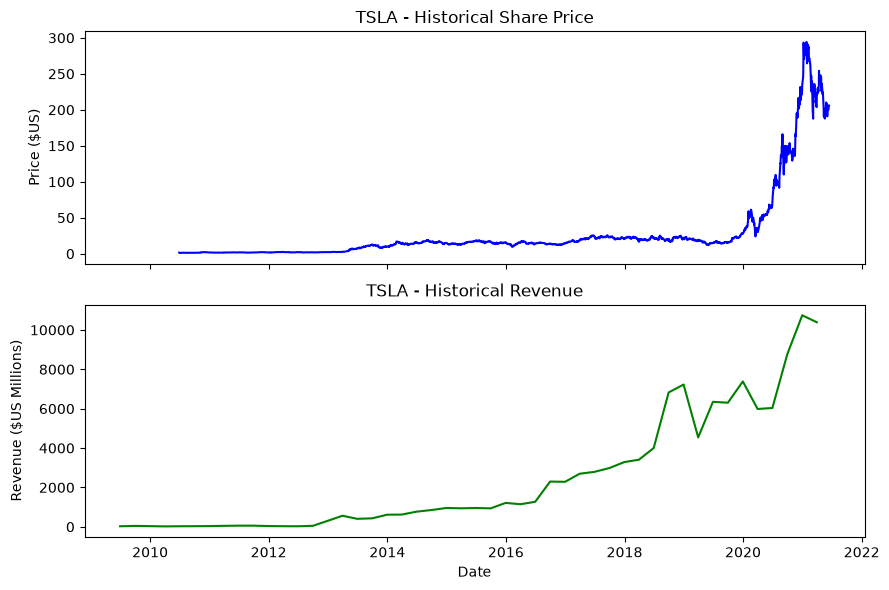

In [71]:
make_graph(tesla_data, tesla_revenue, "TSLA")


## Question 6: Plot GameStop Stock Graph

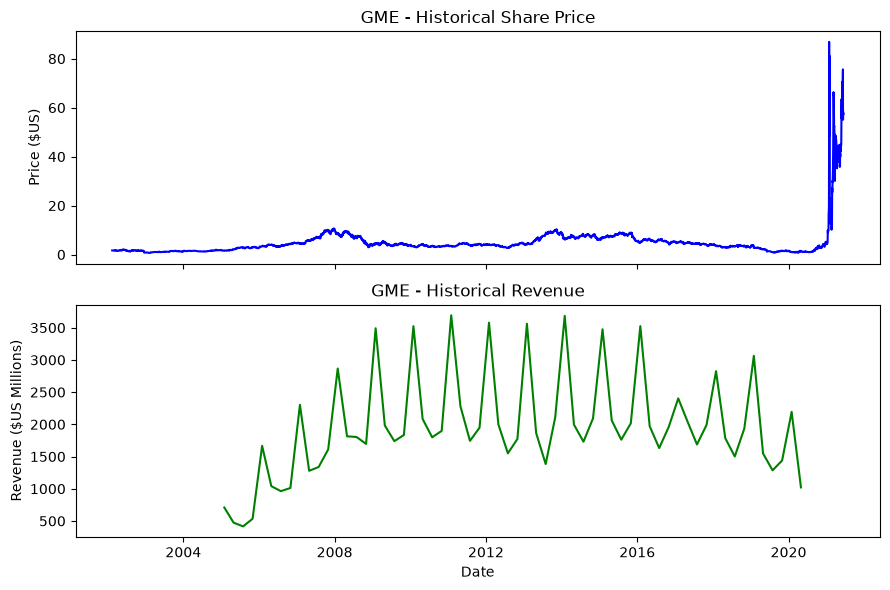

In [72]:
make_graph(gme_data, gme_revenue, 'GME')

## Key observations

- **Tesla:** Share price and quarterly revenue both increased substantially over the period shown, with particularly strong acceleration approaching 2021.
- **GameStop:** The sharp 2021 share-price movement was not accompanied by a comparable sustained rise in revenue.
- **Interpretation:** The contrast illustrates why market price should be considered alongside business fundamentals. These observations are descriptive and do not establish causation.
